#Método del codo para determinación del número de clases en K-Means

Basado en: https://www.geeksforgeeks.org/elbow-method-for-optimal-value-of-k-in-kmeans/

Step 1: Importing the required libraries

In [1]:
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt

Step 2: Creating and Visualizing the data

Se define un conjunto de datos sintético

*Ejercicio propuesto: Modificar este conjunto de datos y volver a correr, preferiblemente haciéndolo más grande.*

In [8]:
# Creating the dataset
x1 = np.array([3, 1, 1, 2, 1, 6, 6, 6, 5, 6, 7, 8, 9, 8, 9, 9, 8, 4, 4, 5, 4])
x2 = np.array([5, 4, 5, 6, 5, 8, 6, 7, 6, 7, 1, 2, 1, 2, 3, 2, 3, 9, 10, 9, 10])
X = np.array(list(zip(x1, x2))).reshape(len(x1), 2)
print(X)
print(X.shape)

[[ 3  5]
 [ 1  4]
 [ 1  5]
 [ 2  6]
 [ 1  5]
 [ 6  8]
 [ 6  6]
 [ 6  7]
 [ 5  6]
 [ 6  7]
 [ 7  1]
 [ 8  2]
 [ 9  1]
 [ 8  2]
 [ 9  3]
 [ 9  2]
 [ 8  3]
 [ 4  9]
 [ 4 10]
 [ 5  9]
 [ 4 10]]
(21, 2)


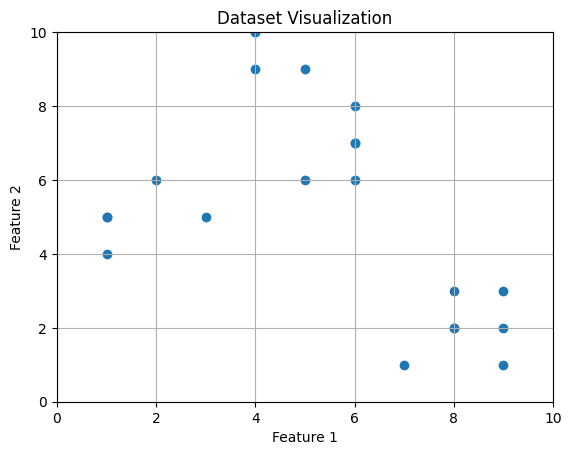

In [3]:
# Visualizing the data
plt.scatter(x1, x2, marker='o')
plt.xlim([0, 10])
plt.ylim([0, 10])
plt.title('Dataset Visualization')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid()
plt.show()

Se visualizan los datos y se nota que no tienen etiqueta (o grupo) definido. Todos son azules.

Step 3: Building the Clustering Model and Calculating Distortion and Inertia

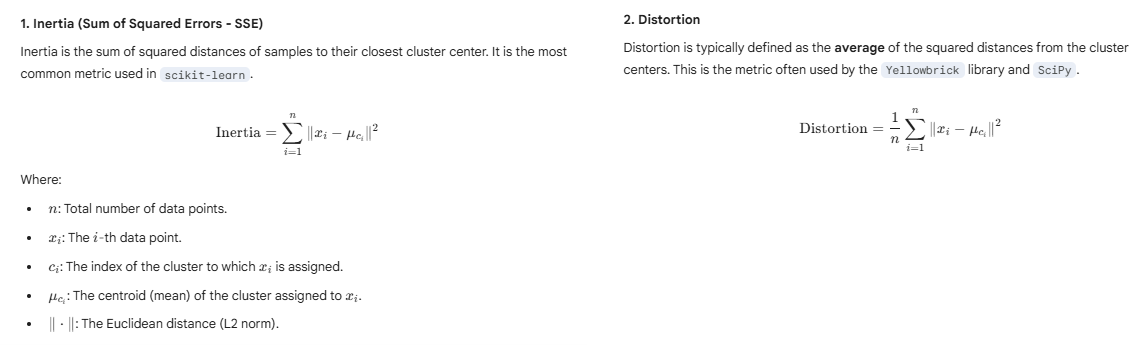

La inercia y la distorsión son los métodos más usados para medir las distancias de las clases (o grupos o clusters) al centroide.

In [4]:
# Initialize lists to store distortion and inertia values
distortions = []  #List
inertias = []     #List
mapping1 = {}     #Dictionary
mapping2 = {}     #Dictionary
K = range(1, 22)

# Fit K-means for different values of k
for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X)

    # Calculate distortion as the average squared distance from points to their cluster centers
    distortions.append(sum(np.min(cdist(X, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X.shape[0])

    # Inertia is calculated directly by KMeans
    inertias.append(kmeanModel.inertia_)

    # Store the mappings for easy access
    mapping1[k] = distortions[-1]
    mapping2[k] = inertias[-1]

print(distortions)
print(mapping1)

[np.float64(14.90249433106576), np.float64(5.146258503401359), np.float64(1.8817838246409675), np.float64(0.856122448979592), np.float64(0.7166666666666667), np.float64(0.5484126984126984), np.float64(0.4325396825396825), np.float64(0.3817460317460318), np.float64(0.3341269841269841), np.float64(0.28253968253968254), np.float64(0.20634920634920637), np.float64(0.17460317460317462), np.float64(0.11111111111111112), np.float64(0.07936507936507937), np.float64(0.05555555555555556), np.float64(0.031746031746031744), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
{1: np.float64(14.90249433106576), 2: np.float64(5.146258503401359), 3: np.float64(1.8817838246409675), 4: np.float64(0.856122448979592), 5: np.float64(0.7166666666666667), 6: np.float64(0.5484126984126984), 7: np.float64(0.4325396825396825), 8: np.float64(0.3817460317460318), 9: np.float64(0.3341269841269841), 10: np.float64(0.28253968253968254), 11: np.float64(0.20634920634920637), 12: np.flo

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (17) found smaller than n_clusters (18). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (17) found smaller than n_clusters (19). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (17) found smaller than n_clusters (20). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (17) found smaller than n_clusters (21). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


Step 4: Tabulating and Visualizing the Results
a) Displaying Distortion Values

Distortion values:
1 : 14.90249433106576
2 : 5.146258503401359
3 : 1.8817838246409675
4 : 0.856122448979592
5 : 0.7166666666666667
6 : 0.5484126984126984
7 : 0.4325396825396825
8 : 0.3817460317460318
9 : 0.3341269841269841
10 : 0.28253968253968254
11 : 0.20634920634920637
12 : 0.17460317460317462
13 : 0.11111111111111112
14 : 0.07936507936507937
15 : 0.05555555555555556
16 : 0.031746031746031744
17 : 0.0
18 : 0.0
19 : 0.0
20 : 0.0
21 : 0.0


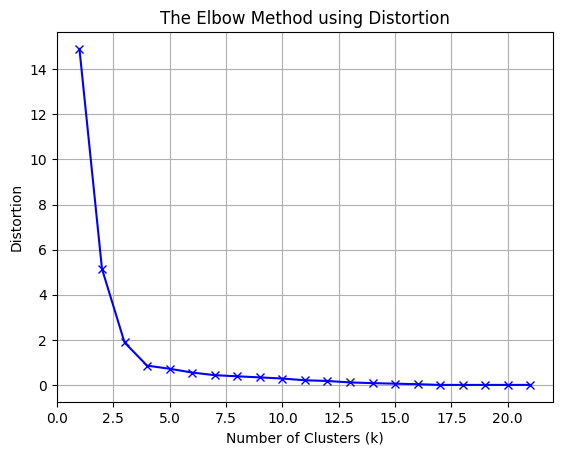

In [5]:
print("Distortion values:")
for key, val in mapping1.items():
    print(f'{key} : {val}')
# Plotting the graph of k versus Distortion
plt.plot(K, distortions, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('The Elbow Method using Distortion')
plt.grid()
plt.show()

Nótese que en la medida que el número de clusters (k) aumenta, las distancias a los k centroides se van reducienco asintóticamente a cero.

b) Displaying Inertia Values:

Inertia values:
1 : 312.95238095238096
2 : 108.07142857142854
3 : 39.51746031746032
4 : 17.978571428571428
5 : 15.049999999999997
6 : 11.516666666666666
7 : 9.083333333333334
8 : 8.016666666666667
9 : 7.0166666666666675
10 : 5.9333333333333345
11 : 4.333333333333333
12 : 3.666666666666667
13 : 2.3333333333333335
14 : 1.666666666666667
15 : 1.1666666666666667
16 : 0.6666666666666666
17 : 0.0
18 : 0.0
19 : 0.0
20 : 0.0
21 : 0.0


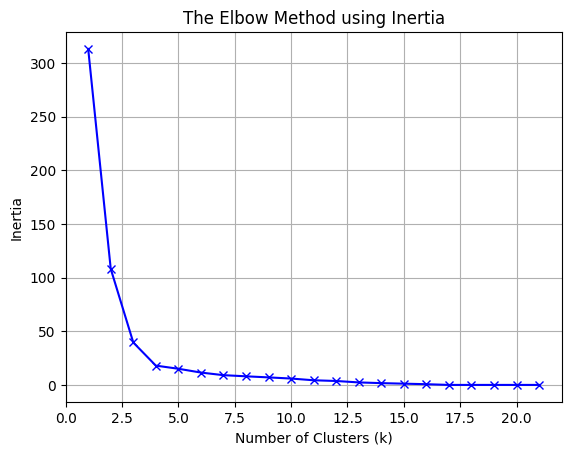

In [6]:
print("Inertia values:")
for key, val in mapping2.items():
    print(f'{key} : {val}')
# Plotting the graph of k versus Inertia
plt.plot(K, inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.grid()
plt.show()

Cuando el número de grupos k es igual a 3 o 4, la curva presenta un codo, por lo tanto se podría decir que este es el valor ideal a seleccionar si se entrena un algoritmo de agrupamiento como K-means.

Step 5: Clustered Data Points For Different k Values

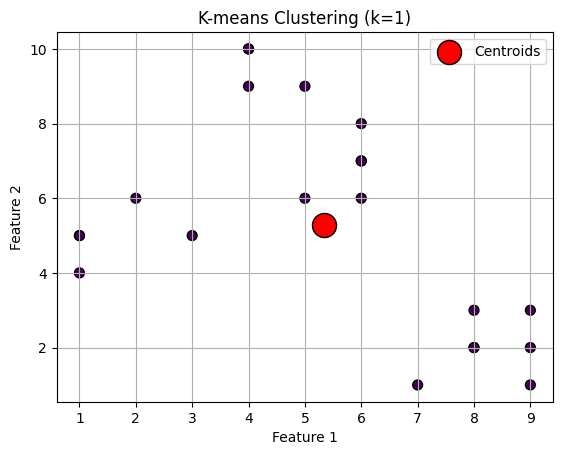

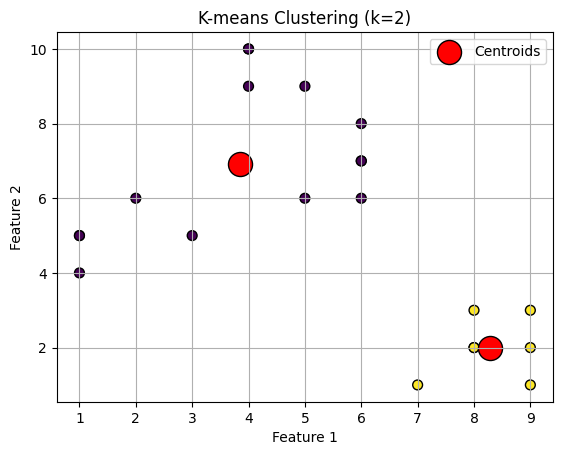

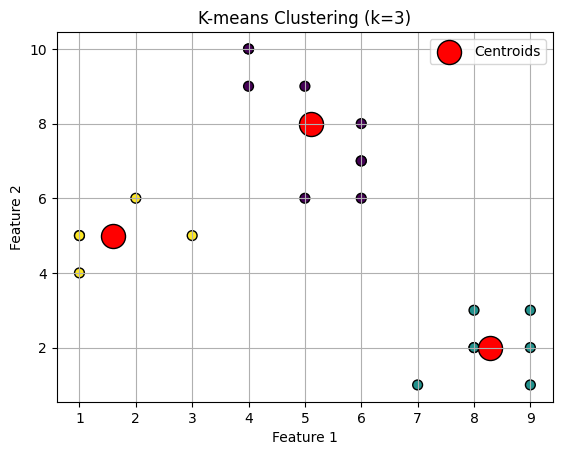

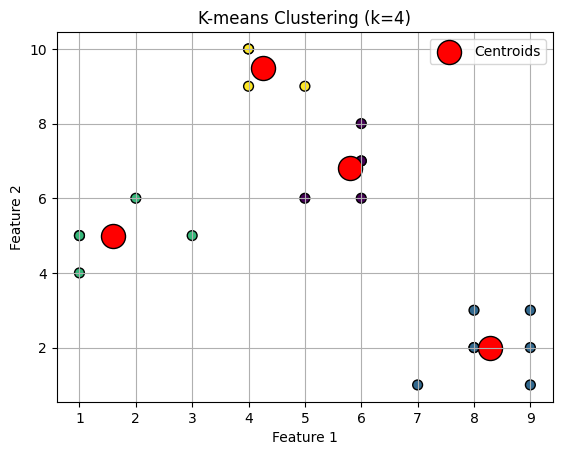

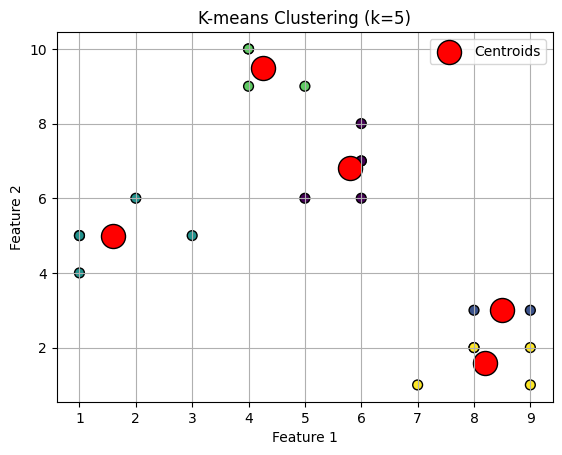

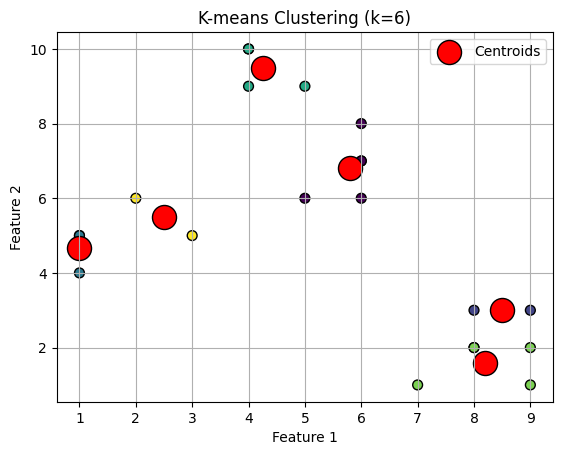

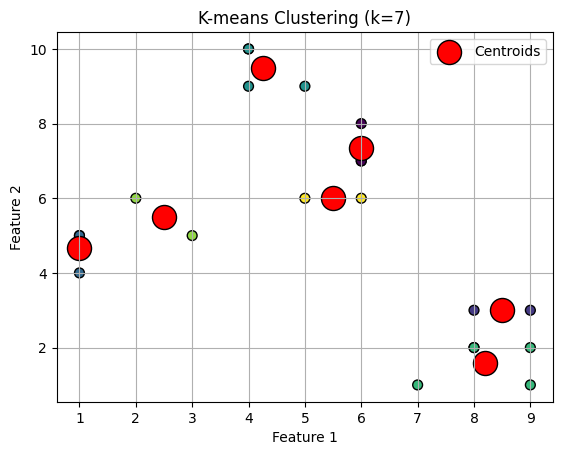

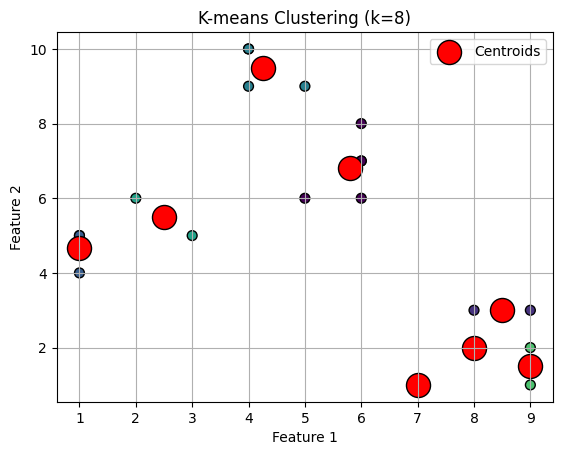

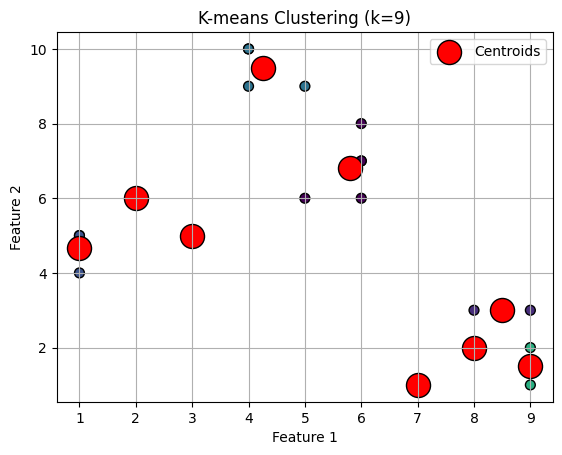

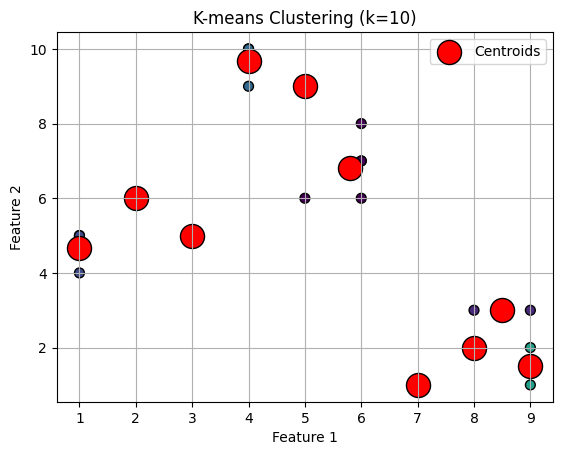

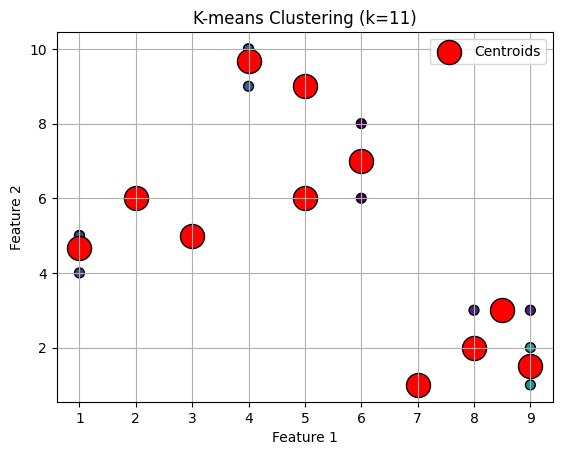

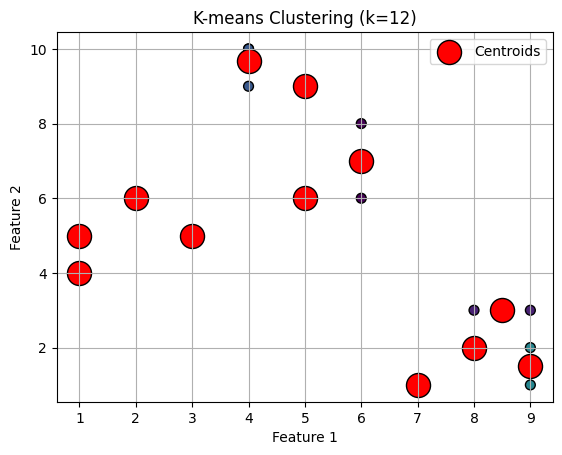

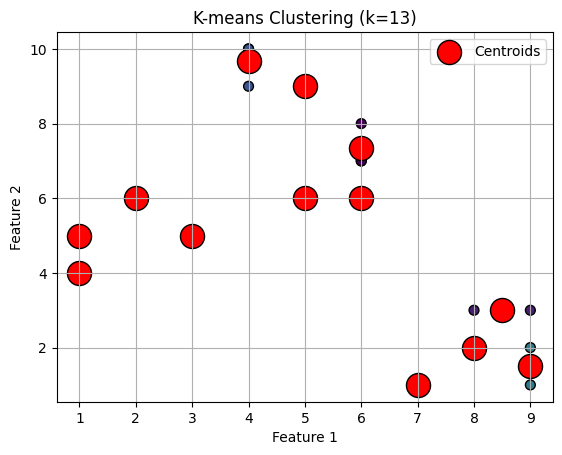

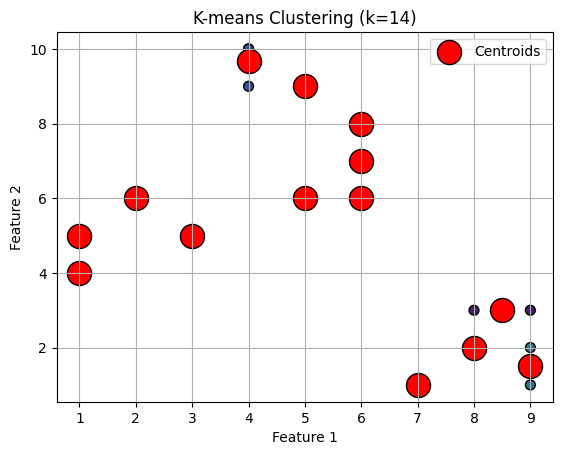

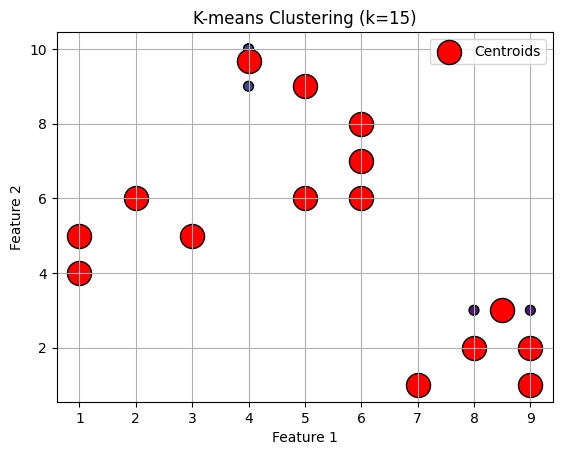

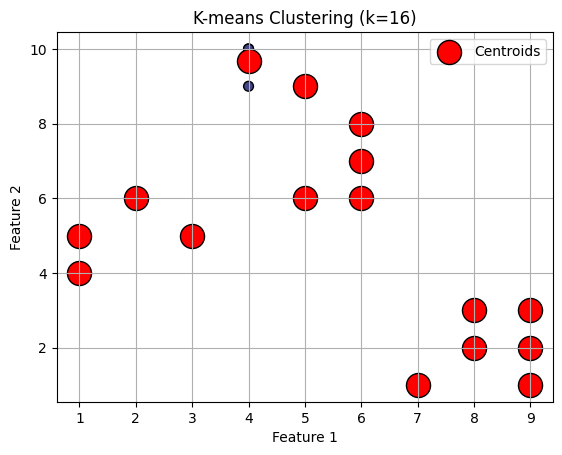

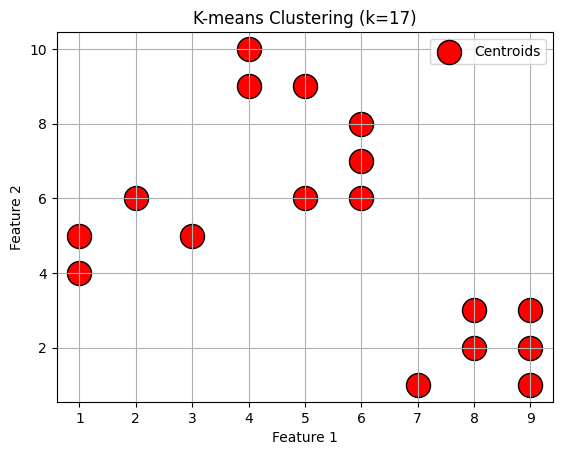

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (17) found smaller than n_clusters (18). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


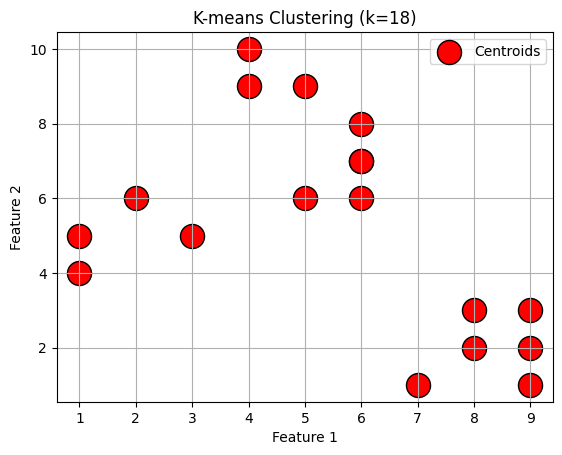

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (17) found smaller than n_clusters (19). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


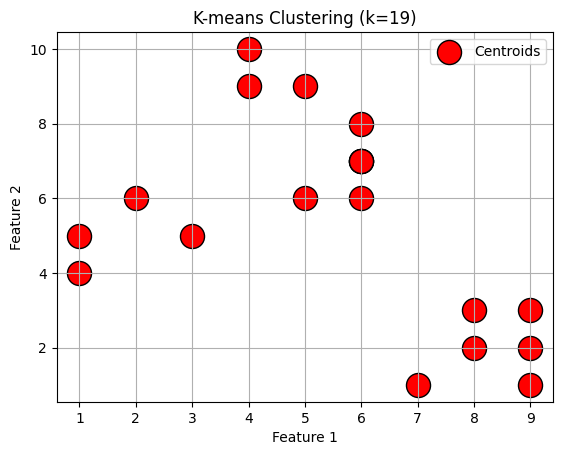

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (17) found smaller than n_clusters (20). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


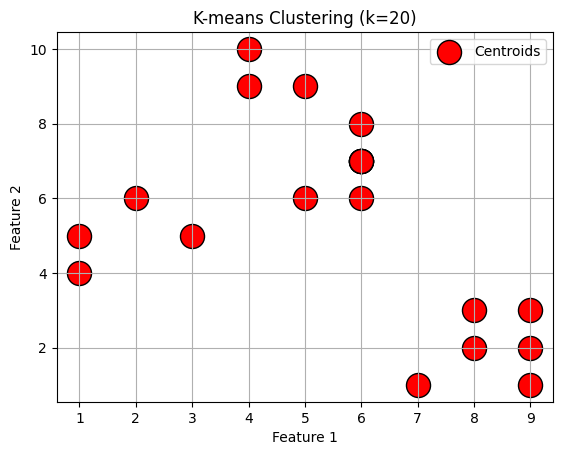

/usr/local/lib/python3.13/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (17) found smaller than n_clusters (21). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


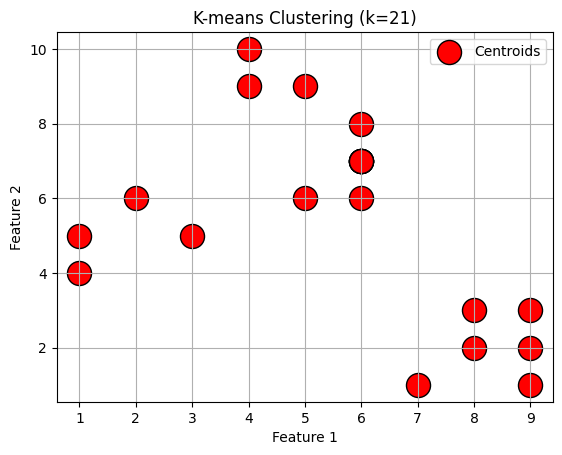

In [7]:
# Initialize a range of k values
k_range = range(1, 22)

# Fit and plot data for each k value
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    y_kmeans = kmeans.fit_predict(X)

    # Plot the clustered data points
    plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='viridis', marker='o', edgecolor='k', s=50)
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', label='Centroids', edgecolor='k')
    plt.title(f'K-means Clustering (k={k})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid()
    plt.show()

En las anteriores simulaciones, se hicieron gráficas desde valores pequeños de k hasta que incluso alcanzó el mismo número de muestras.

Obviamente, no se debe llegar hasta este punto, porque tener k = número de muestras carece de total sentido. Lo que se busca con el agrupamiento es encontrar un k que aporte información, discretizando el conjunto de datos y dando sentido a cada grupo encontrado, es decir, que cada grupo representa un comportamiento particular de todos los datos contenidos en él.

Para este caso particular, k=4 podría ser una elección adecuada con el método del codo.